## Exploratory data analysis (EDA) 

#### is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. 


For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [36]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [37]:
# Load the automobiles dataset
auto_df = pd.read_csv('automobile.txt')
#View the shape of the raw dataset
auto_df.shape

(205, 26)

#### The raw data contains 205 rows and 26 columns

In [38]:
#Display first fifteen rows of the raw dataset
auto_df.head(15)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
5,2,?,audi,gas,std,two,sedan,fwd,front,99.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,15250
6,1,158,audi,gas,std,four,sedan,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,17710
7,1,?,audi,gas,std,four,wagon,fwd,front,105.8,...,136,mpfi,3.19,3.40,8.5,110,5500,19,25,18920
8,1,158,audi,gas,turbo,four,sedan,fwd,front,105.8,...,131,mpfi,3.13,3.40,8.3,140,5500,17,20,23875
9,0,?,audi,gas,turbo,two,hatchback,4wd,front,99.5,...,131,mpfi,3.13,3.40,7.0,160,5500,16,22,?


### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [39]:
#Summarize unique, null and NAN columns adjacent to each other
summary = pd.DataFrame({
    
    'Unique': auto_df.nunique(),
    'Missing (isNULL)': auto_df.isnull().sum(),
    'NaN (isNA)': auto_df.isna().sum(),
    'Question marks': (auto_df == '?').sum()

    })

print(summary.iloc[0:26])

                   Unique  Missing (isNULL)  NaN (isNA)  Question marks
symboling               6                 0           0               0
normalized-losses      52                 0           0              41
make                   22                 0           0               0
fuel-type               2                 0           0               0
aspiration              2                 0           0               0
num-of-doors            3                 0           0               2
body-style              5                 0           0               0
drive-wheels            3                 0           0               0
engine-location         2                 0           0               0
wheel-base             53                 0           0               0
length                 75                 0           0               0
width                  44                 0           0               0
height                 49                 0           0         

#### There appears to be no single value columns and no missing data, however the dataset uses "?" to represent missing values instead of standard NaN values 

In [40]:
#Replace the question marks with standard NaN values
auto_df.replace('?', np.nan, inplace=True)

,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,9.5,114,5400,23,28,16845
201,-1,95,volvo,gas,turbo,four,sedan,rwd,front,109.1,...,141,mpfi,3.78,3.15,8.7,160,5300,19,25,19045
202,-1,95,volvo,gas,std,four,sedan,rwd,front,109.1,...,173,mpfi,3.58,2.87,8.8,134,5500,18,23,21485
203,-1,95,volvo,diesel,turbo,four,sedan,rwd,front,109.1,...,145,idi,3.01,3.40,23.0,106,4800,26,27,22470


In [41]:
#Summarize unique, and missing value counts adjacent to each other
summary = pd.DataFrame({
    
    'Unique': auto_df.nunique(),
    'Missing (isNULL)': auto_df.isnull().sum(),
   
    })

print(summary.iloc[0:26])

                   Unique  Missing (isNULL)
symboling               6                 0
normalized-losses      51                41
make                   22                 0
fuel-type               2                 0
aspiration              2                 0
num-of-doors            2                 2
body-style              5                 0
drive-wheels            3                 0
engine-location         2                 0
wheel-base             53                 0
length                 75                 0
width                  44                 0
height                 49                 0
curb-weight           171                 0
engine-type             7                 0
num-of-cylinders        7                 0
engine-size            44                 0
fuel-system             8                 0
bore                   38                 4
stroke                 36                 4
compression-ratio      32                 0
horsepower             59       

In [42]:
# Drop the columns ['normalized-losses'] and ['symboling']
auto_df.drop('normalized-losses',axis=1, inplace=True)
auto_df.drop('symboling',axis=1, inplace=True)

#view new dataframe shape
auto_df.shape

(205, 24)

#### Remove any duplicate rows

In [43]:
#Check for any duplicated rows in the dataset
duplicates = auto_df[auto_df.duplicated()]
print(duplicates)

Empty DataFrame
Columns: [make, fuel-type, aspiration, num-of-doors, body-style, drive-wheels, engine-location, wheel-base, length, width, height, curb-weight, engine-type, num-of-cylinders, engine-size, fuel-system, bore, stroke, compression-ratio, horsepower, peak-rpm, city-mpg, highway-mpg, price]
Index: []

[0 rows x 24 columns]


In [44]:
# Drop the duplicate rows, if any
auto_df = auto_df.drop_duplicates()
auto_df.shape

(205, 24)

#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [45]:
#Summarize unique, and missing value counts adjacent to each other
summary = pd.DataFrame({
    
    'Unique': auto_df.nunique(),
    'Missing (isNULL)': auto_df.isnull().sum(),
   
    })

print(summary.iloc[0:26])

                   Unique  Missing (isNULL)
make                   22                 0
fuel-type               2                 0
aspiration              2                 0
num-of-doors            2                 2
body-style              5                 0
drive-wheels            3                 0
engine-location         2                 0
wheel-base             53                 0
length                 75                 0
width                  44                 0
height                 49                 0
curb-weight           171                 0
engine-type             7                 0
num-of-cylinders        7                 0
engine-size            44                 0
fuel-system             8                 0
bore                   38                 4
stroke                 36                 4
compression-ratio      32                 0
horsepower             59                 2
peak-rpm               23                 2
city-mpg               29       

In [46]:
#Remove rows with missing data
auto_df = auto_df.dropna()
auto_df.shape


(193, 24)

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [47]:
#Display the data types of the remaining columns in the dataset
auto_df.dtypes

make                     str
fuel-type                str
aspiration               str
num-of-doors             str
body-style               str
drive-wheels             str
engine-location          str
wheel-base           float64
length               float64
width                float64
height               float64
curb-weight            int64
engine-type              str
num-of-cylinders         str
engine-size            int64
fuel-system              str
bore                     str
stroke                   str
compression-ratio    float64
horsepower               str
peak-rpm                 str
city-mpg               int64
highway-mpg            int64
price                    str
dtype: object

In [48]:
# Convert int_columns = ['horsepower', 'peak-rpm','price']
int_columns = ['price', 'horsepower', 'engine-size']
auto_df[int_columns] = auto_df[int_columns].astype('int64')

# Convert float_columns = ['curb-weight', 'bore', 'stroke']
float_columns = ['curb-weight', 'bore', 'stroke']
auto_df[float_columns] = auto_df[float_columns].astype('float64')


In [49]:
#Display dataframe information
auto_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    float64
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    float64

### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [50]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars = auto_df.loc[auto_df['body-style'] == 'hatchback']
hatchback_cars.head(10)

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,...,152,mpfi,2.68,3.47,9.00,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88.4,141.1,60.3,...,61,2bbl,2.91,3.03,9.50,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94.5,155.9,63.6,...,90,2bbl,3.03,3.11,9.60,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.41,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6377
23,dodge,gas,turbo,two,hatchback,fwd,front,93.7,157.3,63.8,...,98,mpfi,3.03,3.39,7.60,102,5500,24,30,7957
24,dodge,gas,std,four,hatchback,fwd,front,93.7,157.3,63.8,...,90,2bbl,2.97,3.23,9.40,68,5500,31,38,6229
29,dodge,gas,turbo,two,hatchback,fwd,front,95.9,173.2,66.3,...,156,mfi,3.60,3.90,7.00,145,5000,19,24,12964
30,honda,gas,std,two,hatchback,fwd,front,86.6,144.6,63.9,...,92,1bbl,2.91,3.41,9.60,58,4800,49,54,6479
31,honda,gas,std,two,hatchback,fwd,front,86.6,144.6,63.9,...,92,1bbl,2.91,3.41,9.20,76,6000,31,38,6855


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some cars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

In [51]:
# determine the five most expensive cars
most_expensive = auto_df.sort_values(by='price', ascending=False).head(5)
print(most_expensive[['make', 'body-style', 'city-mpg', 'highway-mpg', 'price']])


              make   body-style  city-mpg  highway-mpg  price
74   mercedes-benz      hardtop        14           16  45400
16             bmw        sedan        16           22  41315
73   mercedes-benz        sedan        14           16  40960
128        porsche  convertible        17           25  37028
17             bmw        sedan        15           20  36880


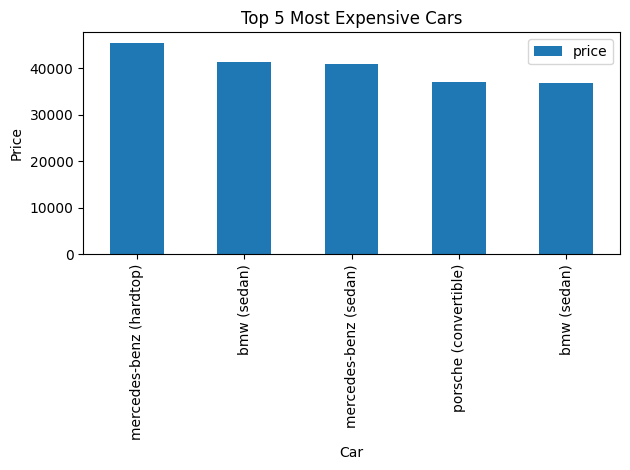

In [52]:
#Create a label that combines manufacturer and body type 
most_expensive['label'] = most_expensive['make'] + ' (' + most_expensive['body-style'] + ')'

#Create bar chart 
most_expensive.plot(
    x='label',
    y='price',
    kind='bar',
    title='Top 5 Most Expensive Cars'
)

plt.xlabel('Car')
plt.ylabel('Price')
#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)
#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

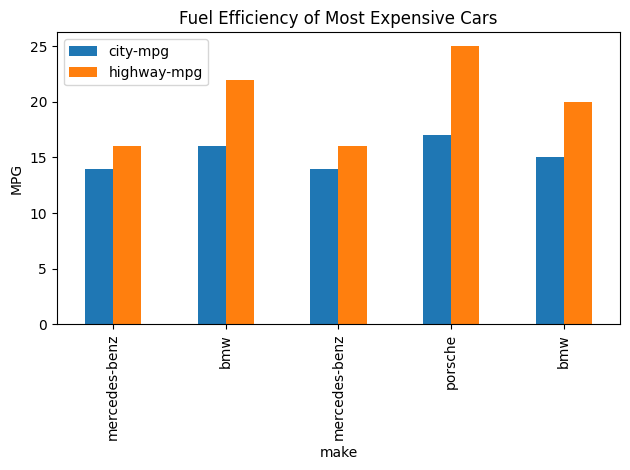

In [53]:
#Create bar chart 
most_expensive.plot(
    x='make',
    y=['city-mpg', 'highway-mpg'],
    kind='bar',
    title='Fuel Efficiency of Most Expensive Cars'
)

plt.ylabel('MPG')
#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)
#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

In [54]:
# determine the five least expensive cars
least_expensive = auto_df.sort_values(by='price', ascending=True).head(5)
print(least_expensive[['make', 'body-style', 'city-mpg', 'highway-mpg', 'price']])

           make body-style  city-mpg  highway-mpg  price
138      subaru  hatchback        31           36   5118
18    chevrolet  hatchback        47           53   5151
50        mazda  hatchback        30           31   5195
150      toyota  hatchback        35           39   5348
76   mitsubishi  hatchback        37           41   5389


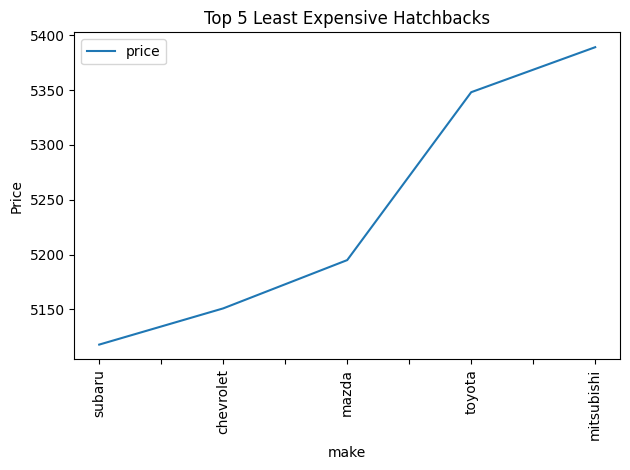

In [55]:
#Create line chart 
least_expensive.plot(
    x='make', 
    y=['price',],
    kind='line',
    title='Top 5 Least Expensive Hatchbacks'
)

plt.ylabel('Price')
#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)
#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

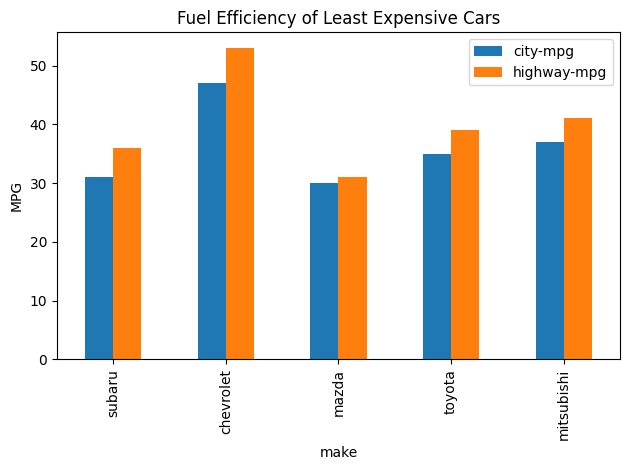

In [56]:
#Create bar chart 
least_expensive.plot(
    x='make',
    y=['city-mpg', 'highway-mpg'],
    kind='bar',
    title='Fuel Efficiency of Least Expensive Cars'
)


plt.ylabel('MPG')
#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)
#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

In [57]:
#Calculate the average consumption in MPG 
expensive_avg = most_expensive[['city-mpg', 'highway-mpg']].mean()
cheap_avg = least_expensive[['city-mpg', 'highway-mpg']].mean()

print("Expensive cars MPG:\n", expensive_avg)
print("\nCheap cars MPG:\n", cheap_avg)

Expensive cars MPG:
 city-mpg       15.2
highway-mpg    19.8
dtype: float64

Cheap cars MPG:
 city-mpg       36.0
highway-mpg    40.0
dtype: float64


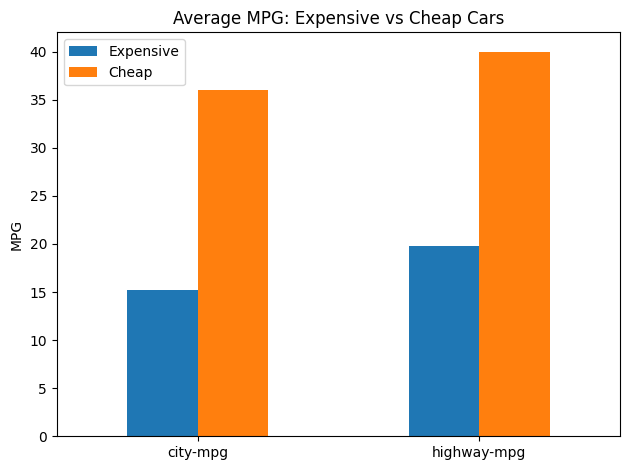

In [58]:
#Compare average consumption for expensive and cheap cars
comparison_df = pd.DataFrame({
    'Expensive': expensive_avg,
    'Cheap': cheap_avg
})

#Create bar chart 
comparison_df.plot(kind='bar', title='Average MPG: Expensive vs Cheap Cars')

plt.ylabel('MPG')
plt.xticks(rotation=0)
#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

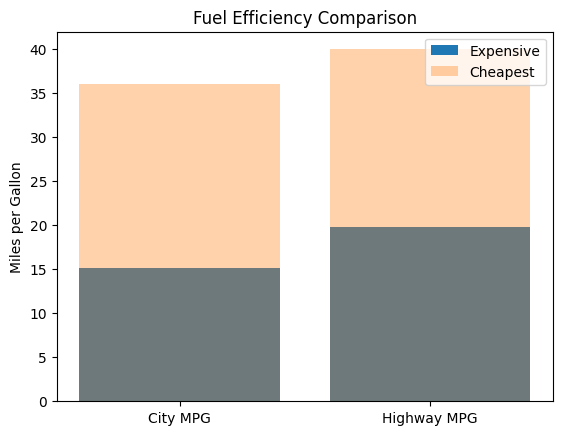

In [59]:
labels = ['City MPG', 'Highway MPG']

x = range(len(labels))

#Superimpose two bar charts for comparison
plt.bar(x, expensive_avg.values, label='Expensive')
plt.bar(x, cheap_avg.values, bottom=expensive_avg.values*0, alpha=0.35, label='Cheapest')

plt.xticks(x, labels)
#Chart title
plt.title('Fuel Efficiency Comparison')
#Add label for y-axis
plt.ylabel('Miles per Gallon')
#Add legend
plt.legend()
plt.show()

In [60]:
#View correlation matrix to see how strongly price and consumption correlate
auto_df[['price', 'city-mpg', 'highway-mpg']].corr()

,price,city-mpg,highway-mpg
price,1.000000,-0.706618,-0.719178
city-mpg,-0.706618,1.000000,0.971975
highway-mpg,-0.719178,0.971975,1.000000


The five most expensive automobiles exhibit significantly lower fuel efficiency compared to the five cheapest automobiles, both in the city and on the highway.
This suggests that more expensive automobiles tend to prioritise appearance, status, power and engine size over fuel efficiency. 
In contrast, the cheapest automobiles demonstrated higher MPG values and therefore lower running costs both in the city and on the highway.

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [61]:
#Calculate the average consumption of the city and highway statistics
auto_df['avg-mpg'] = (auto_df['city-mpg'] + auto_df['highway-mpg']) / 2

#Group by make, brand or manufacturer name
mpg_by_make = auto_df.groupby('make')['avg-mpg'].mean().sort_values(ascending=False)

#Display data
print(mpg_by_make)

make
chevrolet        43.666667
honda            32.923077
volkswagen       31.750000
dodge            31.562500
plymouth         31.142857
mazda            30.958333
toyota           30.203125
nissan           29.972222
subaru           28.541667
mitsubishi       28.038462
isuzu            26.500000
peugot           24.545455
saab             23.833333
alfa-romero      23.500000
volvo            23.500000
bmw              22.375000
audi             21.916667
mercury          21.500000
porsche          21.500000
mercedes-benz    19.750000
jaguar           16.333333
Name: avg-mpg, dtype: float64


In [62]:
#identify the most efficient automobile
most_efficient = mpg_by_make.idxmax()
print("The most fuel-efficient automobile manufacturer is:", most_efficient)

The most fuel-efficient automobile manufacturer is: chevrolet


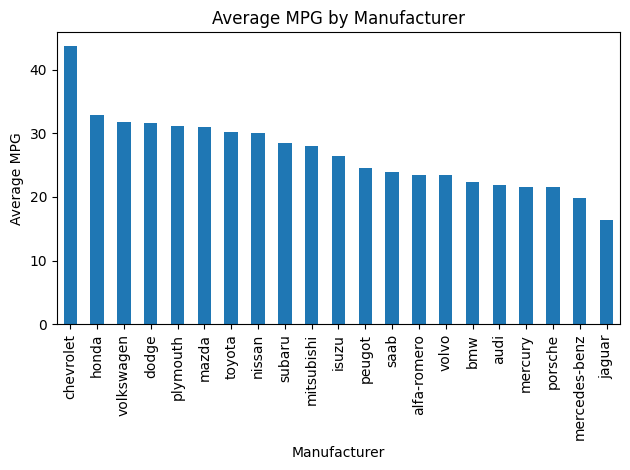

In [63]:
#Create chart to display the average consumption by automobile manufacturer
mpg_by_make.plot(kind='bar')

#Add title, and label axes
plt.title('Average MPG by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Average MPG')

#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)

#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [64]:
# Sort dataset by engine size column
largest_engines = auto_df.sort_values(by='engine-size', ascending=False)

#Display top 5 largest engine sizes 
largest_engines.head(5)[['make', 'body-style', 'engine-size', 'horsepower', 'price']]


,make,body-style,engine-size,horsepower,price
49,jaguar,sedan,326,262,36000
73,mercedes-benz,sedan,308,184,40960
74,mercedes-benz,hardtop,304,184,45400
47,jaguar,sedan,258,176,32250
48,jaguar,sedan,258,176,35550


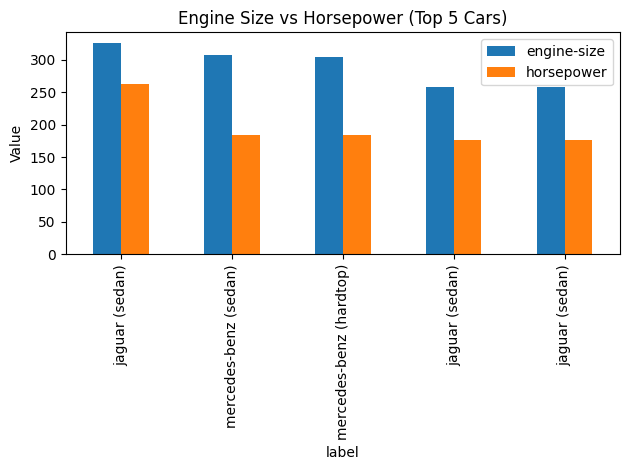

In [65]:
top5 = largest_engines.head(5).copy()
top5['label'] = top5['make'] + ' (' + top5['body-style'] + ')'

#Create bar chart 
top5.plot(
    x='label',
    y=['engine-size', 'horsepower'],
    kind='bar',
    title='Engine Size vs Horsepower (Top 5 Cars)'
)

plt.ylabel('Value')
#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)

#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()

#### Which vehicle manufacturer has the most car models in the dataset

In [66]:
#Count the automibile variants or models by manufacturer
models_per_make = auto_df['make'].value_counts()

#Display Top 10 
models_per_make.head(10)

make
toyota        32
nissan        18
honda         13
mitsubishi    13
mazda         12
subaru        12
volkswagen    12
peugot        11
volvo         11
bmw            8
Name: count, dtype: int64

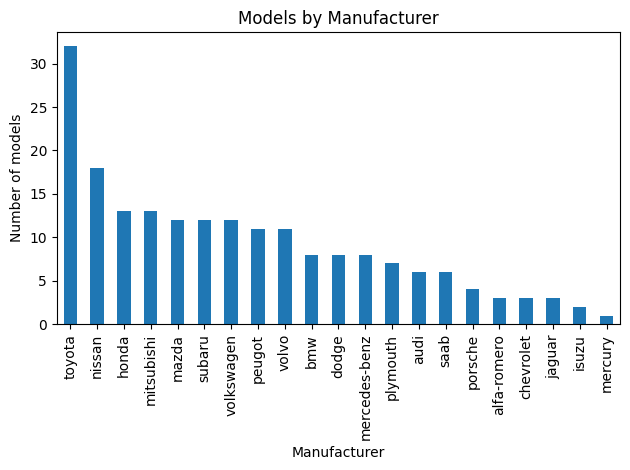

In [67]:
#Create chart to display the model counts by brand or automobile manufacturer
models_per_make.plot(kind='bar')
#Add title, and label axes

#Add title, and label axes
plt.title('Models by Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Number of models')

#Rotate the x-axis labels for easier and more accurate reading
plt.xticks(rotation=90)

#fit subplots within the figure area without overlapping
plt.tight_layout()
plt.show()